## Setup and Configuration

In [1]:
import numpy as np
import os
import pandas as pd
from itertools import product
from collections import defaultdict
from pathlib import Path
import sys

# Add project root to path
ROOT = Path.cwd().parents[1]  # Assumes notebook is in projects/MOSAIC/notebooks/
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

# Import MOSAIC-specific utilities
from pose_dynamics.projects.MOSAIC import (
    extract_keypoints,
    PREDEFINED_SETS,
    preprocess_mosaic_trial,
    get_window_indices,
    build_symmetric_template,
    compute_reference_limb_lengths,
    batch_apply_fixed_lengths,
    align_keypoints,
    rebuild_aligned_dataframe,
    add_custom_features,
    compute_velocity,
    compute_linear_metrics
)

from pose_dynamics.projects.MOSAIC.alignment import order_xy_pairs
from pose_dynamics.projects.MOSAIC.visualization import (
    plot_alignment_diagnostics
)

# Import RQA utilities (C++ backend compiled and ready)
from pose_dynamics.nonlinear.rqa_utils import cross_rqa, auto_rqa, make_rqa_params

print("✓ Imports successful")

✓ Imports successful


## Parameters

In [2]:
# === Data Configuration ===
DATA_PATH = "G:/mosaic movement files"  # Folder containing participant CSV files
AUDIO_CONDITIONS_CSV = "Mosaic_Conditions.csv"  # CSV with session, trial, condition columns

# === ROI Configuration (from PREDEFINED_SETS) ===
# Use predefined keypoint sets for ROI extraction
ROI_KEYPOINT_SETS = ['center_face', 'body', 'arm']

# === Processing Parameters ===
CONF_THRESHOLD = 0.4
MAX_INTERP_GAP = 60
FILTER_CUTOFF = 10.0
FILTER_ORDER = 4
FPS = 60
TARGET_FPS = 30  # Set to downsample (e.g., 30 for 30 Hz), None to keep original

# === Window Parameters ===
WINDOW_SIZE_RQA = 60      # 60 seconds for RQA/CRQA
WINDOW_SIZE_LINEAR = 5    # 5 seconds for linear metrics
WINDOW_OVERLAP = 0.5

# === RQA/CRQA Parameters ===
TIME_LAGS = [15]
EMBEDDING_DIMS = [4]
RADII = [0.15]

# === Alignment Parameters ===
SYMMETRIZATION_MODE = "none"  # Options: "none", "nose", "torso", "full"
ALLOW_ROTATION = True

# === Analysis Target ===
# IMPORTANT: The pipeline analyzes VELOCITY MAGNITUDE (not position) because:
#   1. Procrustes alignment + trial-centering remove positional meaning (arbitrary origin)
#   2. Velocity magnitude = movement speed (origin-independent, meaningful signal)
#   3. All analyses (CRQA/RQA/Linear) consistently analyze movement dynamics
#   4. More interpretable for interpersonal coordination (synchrony of movement, not posture)
USE_VELOCITY = True

# === Output Directories ===
print("✓ Parameters configured")

os.makedirs("../crqa_results", exist_ok=True)
os.makedirs("../rqa_results", exist_ok=True)
os.makedirs("../animations", exist_ok=True)
os.makedirs("../linear_results", exist_ok=True)

✓ Parameters configured


## Pass 1: Load Data and Build Global Template

This pass:
1. Loads all session/trial pose files
2. Extracts relevant keypoints
3. Preprocesses (normalize, mask, interpolate, filter)
4. Slices into windows
5. Builds global symmetric template from all data

In [3]:
raw_windows = []   # (window_df, metadata)
full_trials = []   # for template building
expected_cols = None

print("Loading and preprocessing data...")

# Load audio conditions
audio_df = pd.read_csv(AUDIO_CONDITIONS_CSV)
condition_map = {(int(r["session"]), int(r["trial"])): r["condition"] for _, r in audio_df.iterrows()}
print(f"✓ Loaded audio conditions for {len(condition_map)} session/trial combinations")

# ROI only (speedup)
ROI_KEYPOINT_SETS = ["center_face", "arm", "body"]

print("Processing trials...")

for session_number, trial_number in sorted(condition_map.keys()):
    condition = condition_map[(session_number, trial_number)]

    for role, suffix in [("Left", "left"), ("Right", "right")]:
        filename = f"S{session_number:03}_T{trial_number}_{suffix}.csv"
        filepath = os.path.join(DATA_PATH, filename)

        if not os.path.exists(filepath):
            print(f"[SKIP] {filename} not found")
            continue

        try:
            raw_data = pd.read_csv(filepath)

            # ✅ ROI-only extraction (x/y/conf)
            selected = extract_keypoints(raw_data, sets=ROI_KEYPOINT_SETS)

            # ✅ expected_cols derived from *actual ROI columns* (XY only, ordered)
            if expected_cols is None and not selected.empty:
                expected_cols = order_xy_pairs(selected.columns)
                print(f"✓ Column order established: {len(expected_cols)} columns ({len(expected_cols)//2} keypoints)")

            # Preprocess (XY output; masking uses confidence columns inside `selected`)
            preprocessed = preprocess_mosaic_trial(
                selected,
                expected_cols,
                conf_threshold=CONF_THRESHOLD,
                max_interp_gap=MAX_INTERP_GAP,
                filter_cutoff=FILTER_CUTOFF,
                filter_order=FILTER_ORDER,
                fps=FPS,
                target_fps=TARGET_FPS,   # if you added this param
            )

            full_trials.append(preprocessed)

            # Effective sampling rate after preprocessing
            eff_fps = TARGET_FPS if TARGET_FPS is not None else FPS

            # Convert seconds -> frames
            ws_frames = int(round(WINDOW_SIZE_RQA * eff_fps))

            win_indices = get_window_indices(len(preprocessed), ws_frames, WINDOW_OVERLAP)
            for w_idx, (start, end) in enumerate(win_indices):
                window = preprocessed.iloc[start:end].reset_index(drop=True)

                meta = {
                    "Session": session_number,
                    "Trial": trial_number,
                    "Role": role,
                    "Condition": condition,
                    "Window_Size": WINDOW_SIZE_RQA,  # keep seconds in metadata
                    "Window_Index": w_idx,
                    "Effective_FPS": eff_fps,        # optional but useful
                    "Window_Size_Frames": ws_frames  # optional but useful
                }

                if window.isnull().any().any() or len(window) < ws_frames:
                    raw_windows.append((None, meta))
                else:
                    raw_windows.append((window, meta))

        except Exception as e:
            print(f"Error processing S{session_number:03} T{trial_number} {role}: {e}")
            continue

print(f"\n✓ Loaded {len([w for w, _ in raw_windows if w is not None])} valid windows from {len(full_trials)} trials for (C)RQA")

if not full_trials:
    raise ValueError("No valid trials found for template building")

X_raw = pd.concat(full_trials, ignore_index=True).dropna().astype(np.float32)
global_template = build_symmetric_template(X_raw, expected_cols, mode=SYMMETRIZATION_MODE)
print(f"✓ Global template built: {global_template.shape} with mode='{SYMMETRIZATION_MODE}'")

ref_lengths = None if SYMMETRIZATION_MODE == "nose" else compute_reference_limb_lengths(global_template, expected_cols)
if ref_lengths:
    print(f"✓ Reference limb lengths computed: {len(ref_lengths)} segments")


Loading and preprocessing data...
✓ Loaded audio conditions for 284 session/trial combinations
Processing trials...
✓ Column order established: 124 columns (62 keypoints)
[SKIP] S014_T1_left.csv not found
[SKIP] S014_T2_left.csv not found
[SKIP] S014_T3_left.csv not found
[SKIP] S014_T4_left.csv not found
[SKIP] S014_T5_left.csv not found
[SKIP] S014_T6_left.csv not found
[SKIP] S044_T1_left.csv not found
[SKIP] S044_T1_right.csv not found
[SKIP] S044_T2_left.csv not found
[SKIP] S044_T2_right.csv not found
[SKIP] S044_T3_left.csv not found
[SKIP] S044_T3_right.csv not found
[SKIP] S044_T4_left.csv not found
[SKIP] S044_T4_right.csv not found
[SKIP] S044_T5_left.csv not found
[SKIP] S044_T5_right.csv not found
[SKIP] S044_T6_left.csv not found
[SKIP] S044_T6_right.csv not found

✓ Loaded 4597 valid windows from 550 trials for (C)RQA
✓ Global template built: (62, 2) with mode='none'
✓ Reference limb lengths computed: 4 segments


## Alignment Diagnostics

Visualize alignment quality by comparing raw, aligned, and limb-rescaled poses.

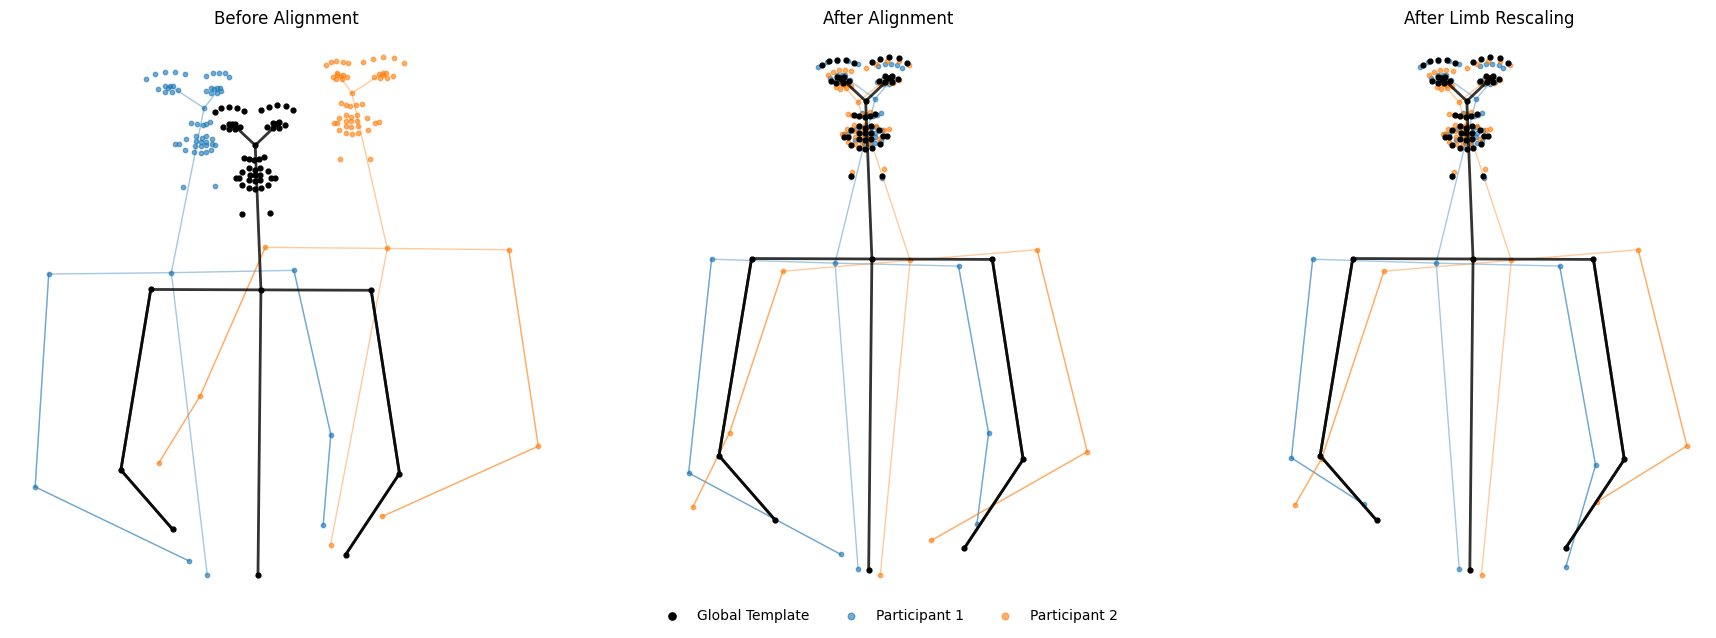

In [4]:
# Sample windows from both Left and Right roles for better visualization
valid_windows = [w for w in raw_windows if w[0] is not None]

# Separate by role
left_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Left']
right_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Right']

# Take samples from each role
sample_windows = []
n_per_role = 1
if left_windows:
    sample_windows.extend(left_windows[:n_per_role])
if right_windows:
    sample_windows.extend(right_windows[:n_per_role])

plot_alignment_diagnostics(
    global_template=global_template,
    raw_windows=sample_windows,
    expected_cols=expected_cols,
    align_keypoints=align_keypoints,
    n_samples=len(sample_windows),
    procrustes=True,
    allow_rotation=ALLOW_ROTATION,
    ref_lengths=ref_lengths,
    reference="Torso"
)

## Pass 2: Align Windows and Prepare for Analysis

This pass:
1. Aligns all windows to global template using Procrustes
2. Applies limb length constraints
3. Computes velocity (via finite differences)
4. Centers data per trial (removes camera angle effects)

Note: Velocity is computed by default because it's origin-independent and more interpretable for coordination analysis than position after normalization.

In [5]:
from collections import defaultdict

aligned_windows = []
metadata = []

print("Aligning windows...")

eff_fps = TARGET_FPS if TARGET_FPS is not None else FPS
expected_cols_xy = expected_cols  # already XY-only

for window, meta in raw_windows:
    if window is None:
        aligned_windows.append(None)
        metadata.append(meta)
        continue

    try:
        window_xy = window[expected_cols_xy]

        aligned_X, _ = align_keypoints(
            window_xy,
            expected_cols_xy,
            reference="Torso" if SYMMETRIZATION_MODE != "nose" else "Nose",
            template=global_template,
            use_procrustes=True,
            allow_rotation=ALLOW_ROTATION,
            allow_scale=True
        )

        poses = aligned_X.reshape(-1, len(expected_cols_xy) // 2, 2)
        if ref_lengths:
            poses = batch_apply_fixed_lengths(poses, ref_lengths)

        aligned_df = rebuild_aligned_dataframe(
            poses.reshape(-1, len(expected_cols_xy)),
            expected_cols_xy
        )

        aligned_windows.append(aligned_df)
        metadata.append(meta)

    except Exception as e:
        aligned_windows.append(None)
        metadata.append(meta)
        print(f"[ALIGN SKIP] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']}: {e}")

print(f"✓ Aligned {sum(w is not None for w in aligned_windows)} windows")

# ------------------------------------------------------------------
# Trial-centered normalization on POSITION (XY), then velocity
# ------------------------------------------------------------------
trial_groups = defaultdict(list)
for i, meta in enumerate(metadata):
    df = aligned_windows[i]
    if df is None:
        continue
    key = (meta["Session"], meta["Trial"], meta["Role"])
    trial_groups[key].append((i, df))

final_windows = [None] * len(aligned_windows)

for indices_and_data in trial_groups.values():
    # compute trial mean on position columns
    trial_df = pd.concat([df for _, df in indices_and_data], ignore_index=True)
    trial_mean = trial_df.mean(numeric_only=True)

    for idx, df in indices_and_data:
        # centre positions first
        centred = df - trial_mean

        # then compute velocity (signed vx/vy)
        if USE_VELOCITY:
            centred = compute_velocity(centred, fps=eff_fps)

        final_windows[idx] = centred

print("✓ Trial-centered normalization complete (positions), velocity computed")


Aligning windows...
✓ Aligned 4597 windows
✓ Trial-centered normalization complete (positions), velocity computed


## Pass 3: Extract ROI Magnitude Vectors

Collapse each ROI's keypoint data into a single scalar per frame:
- Compute centroid: mean (x, y) across all keypoints in ROI
- Compute magnitude: Euclidean norm of centroid
- Result: single scalar time series per ROI (speed if velocity, position if USE_VELOCITY=False)

Regions of Interest:
- **Centre-face**: Central facial and head region

- **Upper body**: Torso and shoulder region

- **Arms**: Upper and lower arm movementsThese collapsed vectors are then analyzed by CRQA (dyadic), RQA (individual), and linear metrics (descriptive).


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# Collapse keypoints -> ROI centroid (mean vx/vy or mean x/y) + magnitude
# ROIs: center_face, body, arms (combined)
# ============================================================

def build_roi_columns(expected_cols, combine_arms=True):
    """
    Build ROI -> (x_cols, y_cols) from the columns that actually exist.

    Works for:
      - position columns: *_x_offset, *_y_offset
      - velocity columns: *_vx, *_vy
    """
    is_velocity = any(c.endswith("_vx") or c.endswith("_vy") for c in expected_cols)
    x_suffix = "_vx" if is_velocity else "_x_offset"
    y_suffix = "_vy" if is_velocity else "_y_offset"

    roi_map = {}

    # --- centre_face ---
    bases = PREDEFINED_SETS["center_face"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in bases)]
    roi_map["center_face"] = (x_cols, y_cols)

    # --- body ---
    bases = PREDEFINED_SETS["body"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in bases)]
    roi_map["body"] = (x_cols, y_cols)

    # --- arms (combined) ---
    arm_bases = PREDEFINED_SETS["arm"]  # ["Shoulder", "Elbow", "Wrist"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in arm_bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in arm_bases)]
    roi_map["arms"] = (x_cols, y_cols)

    return roi_map


def collapse_window_to_roi_timeseries(window_df: pd.DataFrame, x_cols, y_cols, roi_name: str) -> pd.DataFrame:
    """
    Collapse ROI keypoints to centroid (mean x, mean y) and magnitude.
    For velocity data: centroid vx/vy and speed magnitude.
    For position data: centroid x/y and position magnitude (less meaningful post-alignment).
    """
    if len(x_cols) == 0 or len(y_cols) == 0:
        raise ValueError(f"{roi_name}: no matching columns found (x={len(x_cols)}, y={len(y_cols)})")

    cx = window_df[x_cols].mean(axis=1)
    cy = window_df[y_cols].mean(axis=1)
    mag = np.sqrt(cx**2 + cy**2)

    return pd.DataFrame({
        f"{roi_name}_x": cx,
        f"{roi_name}_y": cy,
        f"{roi_name}_mag": mag
    })


# ============================================================
# Choose which windows to collapse
# - Recommended:
#   * If USE_VELOCITY=True and you followed the earlier fix:
#       final_windows contains vx/vy already -> collapse those
#   * If USE_VELOCITY=False:
#       use aligned_windows (trial-centered positions if you created them)
# ============================================================

windows_for_roi = final_windows if USE_VELOCITY else aligned_windows

# Grab a representative non-None window to detect column suffixes
first_valid_idx = next(i for i, w in enumerate(windows_for_roi) if w is not None)
cols_in_use = list(windows_for_roi[first_valid_idx].columns)

roi_map = build_roi_columns(cols_in_use)

roi_windows = {roi: [] for roi in roi_map.keys()}
roi_metadata = {roi: [] for roi in roi_map.keys()}

print("Extracting ROI centroid + magnitude...")

for w, meta in zip(windows_for_roi, metadata):
    if w is None:
        for roi in roi_windows:
            roi_windows[roi].append(None)
            roi_metadata[roi].append(meta)
        continue

    for roi, (x_cols, y_cols) in roi_map.items():
        try:
            roi_df = collapse_window_to_roi_timeseries(w, x_cols, y_cols, roi)

            meta_roi = meta.copy()
            meta_roi["ROI"] = roi
            meta_roi["ROI_n_keypoints"] = len(x_cols)
            meta_roi["ROI_signal"] = "speed" if USE_VELOCITY else "position_magnitude"

            roi_windows[roi].append(roi_df)
            roi_metadata[roi].append(meta_roi)

        except Exception as e:
            print(f"[ROI SKIP] {roi} S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']}: {e}")
            roi_windows[roi].append(None)
            roi_metadata[roi].append(meta)

print("\nROI extraction diagnostics:")
for roi in roi_windows:
    n_valid = sum(df is not None for df in roi_windows[roi])
    print(f"  {roi:>11}: {n_valid} valid windows")


Extracting ROI centroid + magnitude...

ROI extraction diagnostics:
  center_face: 4597 valid windows
         body: 4597 valid windows
         arms: 4597 valid windows


## Pass 4: CRQA Analysis - Movement Synchrony

Analyze interpersonal movement synchrony between Left and Right participants using cross-recurrence on ROI speed magnitude vectors.


Interpretation: How much do the two participants' movements in each ROI co-recur? Higher REC/DET suggests synchronized movement dynamics.

In [7]:
from collections import defaultdict
from itertools import product
import numpy as np
import pandas as pd

# ============================================================
# CRQA on ROI magnitude only (1D signal per ROI per window)
# roi_windows[roi] contains DataFrames with columns: f"{roi}_x", f"{roi}_y", f"{roi}_mag"
# roi_metadata[roi] contains matching metadata dicts (incl. Session/Trial/Role/Condition/Window_Size/Window_Index)
# ============================================================

print("\nRunning CRQA on ROI magnitude vectors...")

for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"CRQA ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    # --- pair up Left/Right by (Session, Trial, Window_Index) ---
    paired = defaultdict(dict)
    for df_roi, meta in zip(roi_windows[roi], roi_metadata[roi]):
        if df_roi is None:
            continue
        key = (meta["Session"], meta["Trial"], meta["Window_Index"])
        paired[key][meta["Role"]] = (df_roi, meta)

    print(f"Found {len(paired)} potential window pairs")

    csv_rows = []
    n_pairs_run = 0

    for (sess, trial, w_idx), roles in paired.items():
        if "Left" not in roles or "Right" not in roles:
            continue

        left_df, left_meta = roles["Left"]
        right_df, right_meta = roles["Right"]

        # magnitude (1D)
        left_vec = left_df[f"{roi}_mag"].to_numpy(dtype=float)
        right_vec = right_df[f"{roi}_mag"].to_numpy(dtype=float)

        # safety: same length + finite
        if left_vec.shape[0] != right_vec.shape[0]:
            continue
        if not (np.isfinite(left_vec).all() and np.isfinite(right_vec).all()):
            continue

        for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
            params = make_rqa_params(
                eDim=emb_dim,
                tLag=lag,
                radius=rad,
                norm="zscore",
                rescaleNorm=1,
                tw=0,     # no Theiler window for cross-RQA
                minl=2
            )

            try:
                td, rs, mats, err_code = cross_rqa(
                    left_vec,
                    right_vec,
                    params,
                    return_mats=False
                )

                if n_pairs_run % 250 == 0:
                    rec_val = rs.get("perc_recur", np.nan)
                    print(f"[CRQA] S{sess:03} T{trial} W{w_idx} -> REC={rec_val:.2f}% (lag={lag}, m={emb_dim}, r={rad})")

                csv_rows.append({
                    "Session": sess,
                    "Trial": trial,
                    "Condition": left_meta.get("Condition", np.nan),
                    "Window_Size": left_meta.get("Window_Size", np.nan),
                    "Window_Index": w_idx,
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "CRQA_REC": rs.get("perc_recur", np.nan),
                    "CRQA_DET": rs.get("perc_determ", np.nan),
                    "CRQA_Lmean": rs.get("mean_line_length", np.nan),
                    "CRQA_Lmax": rs.get("maxl_found", np.nan),
                    "CRQA_ENT": rs.get("entropy", np.nan),
                    "CRQA_LAM": rs.get("laminarity", np.nan),
                    "CRQA_TT": rs.get("trapping_time", np.nan),
                })

                n_pairs_run += 1

            except Exception as e:
                print(f"[ERROR] CRQA failed S{sess:03} T{trial} W{w_idx} ROI={roi}: {e}")
                csv_rows.append({
                    "Session": sess,
                    "Trial": trial,
                    "Condition": left_meta.get("Condition", np.nan),
                    "Window_Size": left_meta.get("Window_Size", np.nan),
                    "Window_Index": w_idx,
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "CRQA_REC": np.nan,
                    "CRQA_DET": np.nan,
                    "CRQA_Lmean": np.nan,
                    "CRQA_Lmax": np.nan,
                    "CRQA_ENT": np.nan,
                    "CRQA_LAM": np.nan,
                    "CRQA_TT": np.nan,
                })

    # --- save ---
    if csv_rows:
        # make filename informative but stable
        out_path = f"../crqa_results/crqa_{roi}_mag_R{int(RADII[0]*100)}.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ CRQA results saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid CRQA results for ROI={roi}")

print(f"\n{'='*60}")
print("CRQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



Running CRQA on ROI magnitude vectors...

CRQA ANALYSIS: CENTER_FACE (magnitude only)
Found 2867 potential window pairs
[CRQA] S002 T1 W0 -> REC=1.52% (lag=15, m=4, r=0.15)
[CRQA] S007 T4 W1 -> REC=1.08% (lag=15, m=4, r=0.15)
[CRQA] S013 T4 W7 -> REC=1.32% (lag=15, m=4, r=0.15)
[CRQA] S020 T2 W8 -> REC=0.65% (lag=15, m=4, r=0.15)
[CRQA] S025 T3 W3 -> REC=0.76% (lag=15, m=4, r=0.15)
[CRQA] S033 T1 W5 -> REC=1.04% (lag=15, m=4, r=0.15)
[CRQA] S041 T1 W1 -> REC=2.18% (lag=15, m=4, r=0.15)
✓ CRQA results saved → ../crqa_results/crqa_center_face_mag_R15.csv  (rows=1730)

CRQA ANALYSIS: BODY (magnitude only)
Found 2867 potential window pairs
[CRQA] S002 T1 W0 -> REC=0.23% (lag=15, m=4, r=0.15)
[CRQA] S007 T4 W1 -> REC=0.26% (lag=15, m=4, r=0.15)
[CRQA] S013 T4 W7 -> REC=0.43% (lag=15, m=4, r=0.15)
[CRQA] S020 T2 W8 -> REC=0.52% (lag=15, m=4, r=0.15)
[CRQA] S025 T3 W3 -> REC=0.19% (lag=15, m=4, r=0.15)
[CRQA] S033 T1 W5 -> REC=0.46% (lag=15, m=4, r=0.15)
[CRQA] S041 T1 W1 -> REC=0.57% (lag=1

## Pass 5: RQA Analysis - Individual Movement Dynamics

Analyze recurrence patterns within each individual's ROI speed magnitude trajectories.


Interpretation: How predictable/structured is each person's movement in each ROI? Higher REC/DET suggests more periodic/repetitive movement patterns.

In [8]:
from itertools import product
import numpy as np
import pandas as pd

# ============================================================
# RQA on ROI magnitude only (1D signal per ROI per window per role)
# roi_windows[roi] : list of ROI DataFrames (or None), each has f"{roi}_mag"
# roi_metadata[roi]: matching list of meta dicts
# ============================================================

print("\nRunning RQA on ROI magnitude vectors...")

for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"RQA ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    csv_rows = []
    n_run = 0

    roi_list = roi_windows[roi]
    meta_list = roi_metadata[roi]

    print(f"\nRunning RQA on magnitude vectors ({len(meta_list)} windows)...")

    for df_roi, meta in zip(roi_list, meta_list):
        # If missing window -> write NaNs for all parameter combos
        if df_roi is None:
            for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })
            continue

        vec = df_roi[f"{roi}_mag"].to_numpy(dtype=float)

        # safety: finite only
        if not np.isfinite(vec).all():
            for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })
            continue

        for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
            params = make_rqa_params(
                eDim=emb_dim,
                tLag=lag,
                radius=rad,
                norm="zscore",
                rescaleNorm=1,
                tw=2,   # Theiler window for auto-RQA
                minl=2
            )

            try:
                td, rs, mats, err_code = auto_rqa(
                    vec,
                    params,
                    return_mats=False
                )

                if n_run % 500 == 0:
                    rec_val = rs.get("perc_recur", np.nan)
                    print(f"[RQA] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']} -> REC={rec_val:.2f}% (lag={lag}, m={emb_dim}, r={rad})")

                lmax = rs.get("maxl_found", np.nan)
                ws = meta.get("Window_Size", None)
                p_lmax = (lmax / ws) if (isinstance(lmax, (int, float)) and isinstance(ws, (int, float)) and ws) else np.nan

                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": rs.get("perc_recur", np.nan),
                    "RQA_DET": rs.get("perc_determ", np.nan),
                    "RQA_Lmean": rs.get("mean_line_length", np.nan),
                    "RQA_Lmax": lmax,
                    "RQA_pLmax": p_lmax,
                    "RQA_ENT": rs.get("entropy", np.nan),
                    "RQA_LAM": rs.get("laminarity", np.nan),
                    "RQA_TT": rs.get("trapping_time", np.nan),
                })

                n_run += 1

            except Exception as e:
                print(f"[ERROR] RQA failed S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']} ROI={roi}: {e}")
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })

    # --- save ---
    if csv_rows:
        out_path = f"../rqa_results/rqa_{roi}_mag_R{int(RADII[0]*100)}.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ RQA results saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid RQA results for ROI={roi}")

print(f"\n{'='*60}")
print("RQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



Running RQA on ROI magnitude vectors...

RQA ANALYSIS: CENTER_FACE (magnitude only)

Running RQA on magnitude vectors (6344 windows)...
[RQA] S002 T1 Left W0 -> REC=1.30% (lag=15, m=4, r=0.15)
[RQA] S006 T6 Left W8 -> REC=0.31% (lag=15, m=4, r=0.15)
[RQA] S011 T3 Left W5 -> REC=5.32% (lag=15, m=4, r=0.15)
[RQA] S016 T3 Right W2 -> REC=1.71% (lag=15, m=4, r=0.15)
[RQA] S021 T2 Left W5 -> REC=0.65% (lag=15, m=4, r=0.15)
[RQA] S025 T4 Left W0 -> REC=6.86% (lag=15, m=4, r=0.15)
[RQA] S030 T5 Left W5 -> REC=0.72% (lag=15, m=4, r=0.15)
[RQA] S037 T1 Left W0 -> REC=0.50% (lag=15, m=4, r=0.15)
[RQA] S042 T3 Left W1 -> REC=1.39% (lag=15, m=4, r=0.15)
[RQA] S049 T1 Right W7 -> REC=0.96% (lag=15, m=4, r=0.15)
✓ RQA results saved → ../rqa_results/rqa_center_face_mag_R15.csv  (rows=6344)

RQA ANALYSIS: BODY (magnitude only)

Running RQA on magnitude vectors (6344 windows)...
[RQA] S002 T1 Left W0 -> REC=0.19% (lag=15, m=4, r=0.15)
[RQA] S006 T6 Left W8 -> REC=0.23% (lag=15, m=4, r=0.15)
[RQA] S011

## Pass 6: Linear Metrics Analysis - Movement Summary Statistics

Compute summary statistics on each ROI's speed magnitude trajectory (RMS, velocity derivatives, acceleration).


Metrics capture: average movement intensity (RMS), how much the speed varies (StdVel), acceleration patterns (MeanAcc, StdAcc).

In [9]:
import numpy as np
import pandas as pd

# ============================================================
# Linear metrics on ROI magnitude only (1D per ROI per window per role)
# roi_windows[roi] : list of ROI DataFrames (or None), each has f"{roi}_mag"
# roi_metadata[roi]: matching list of meta dicts
# compute_linear_metrics(series, fps=...) should accept 1D array
# ============================================================

print("\nComputing linear metrics on ROI magnitude vectors...")

for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"LINEAR METRICS ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    csv_rows = []
    n_done = 0

    roi_list = roi_windows[roi]
    meta_list = roi_metadata[roi]

    print(f"\nComputing linear metrics on magnitude vectors ({len(meta_list)} windows)...")

    for df_roi, meta in zip(roi_list, meta_list):
        # Missing window -> NaNs
        if df_roi is None:
            csv_rows.append({
                "Session": meta["Session"],
                "Trial": meta["Trial"],
                "Role": meta["Role"],
                "Condition": meta.get("Condition", np.nan),
                "Window_Size": meta.get("Window_Size", np.nan),
                "Window_Index": meta["Window_Index"],
                "ROI": roi,
                "Vector_Type": "magnitude",
                "RMS": np.nan,
                "MeanVel": np.nan,
                "StdVel": np.nan,
                "MeanAcc": np.nan,
                "StdAcc": np.nan,
                "MeanVelMag": np.nan,
                "StdVelMag": np.nan,
                "MeanAccelMag": np.nan,
                "StdAccelMag": np.nan,
            })
            continue

        series = df_roi[f"{roi}_mag"].to_numpy(dtype=float)

        # Non-finite -> NaNs
        if not np.isfinite(series).all():
            csv_rows.append({
                "Session": meta["Session"],
                "Trial": meta["Trial"],
                "Role": meta["Role"],
                "Condition": meta.get("Condition", np.nan),
                "Window_Size": meta.get("Window_Size", np.nan),
                "Window_Index": meta["Window_Index"],
                "ROI": roi,
                "Vector_Type": "magnitude",
                "RMS": np.nan,
                "MeanVel": np.nan,
                "StdVel": np.nan,
                "MeanAcc": np.nan,
                "StdAcc": np.nan,
                "MeanVelMag": np.nan,
                "StdVelMag": np.nan,
                "MeanAccelMag": np.nan,
                "StdAccelMag": np.nan,
            })
            continue

        # Compute metrics
        metrics = compute_linear_metrics(series, fps=FPS)

        if n_done % 500 == 0:
            print(
                f"[Linear] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} "
                f"W{meta['Window_Index']} -> RMS={metrics.get('RMS', np.nan):.4f}"
            )

        csv_rows.append({
            "Session": meta["Session"],
            "Trial": meta["Trial"],
            "Role": meta["Role"],
            "Condition": meta.get("Condition", np.nan),
            "Window_Size": meta.get("Window_Size", np.nan),
            "Window_Index": meta["Window_Index"],
            "ROI": roi,
            "Vector_Type": "magnitude",
            **metrics,
        })

        n_done += 1

    # Save
    if csv_rows:
        out_path = f"../linear_results/linear_{roi}_mag.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ Linear metrics saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid linear metrics for ROI={roi}")

print(f"\n{'='*60}")
print("LINEAR METRICS ANALYSIS COMPLETE")
print(f"{'='*60}\n")



Computing linear metrics on ROI magnitude vectors...

LINEAR METRICS ANALYSIS: CENTER_FACE (magnitude only)

Computing linear metrics on magnitude vectors (6344 windows)...
[Linear] S002 T1 Left W0 -> RMS=0.0213
[Linear] S006 T6 Left W8 -> RMS=0.0209
[Linear] S011 T3 Left W5 -> RMS=0.0295
[Linear] S016 T3 Right W2 -> RMS=0.0218
[Linear] S021 T2 Left W5 -> RMS=0.0741
[Linear] S025 T4 Left W0 -> RMS=0.0852
[Linear] S030 T5 Left W5 -> RMS=0.0108
[Linear] S037 T1 Left W0 -> RMS=0.0323
[Linear] S042 T3 Left W1 -> RMS=0.0209
[Linear] S049 T1 Right W7 -> RMS=0.0552
✓ Linear metrics saved → ../linear_results/linear_center_face_mag.csv  (rows=6344)

LINEAR METRICS ANALYSIS: BODY (magnitude only)

Computing linear metrics on magnitude vectors (6344 windows)...
[Linear] S002 T1 Left W0 -> RMS=0.0204
[Linear] S006 T6 Left W8 -> RMS=0.0301
[Linear] S011 T3 Left W5 -> RMS=0.0294
[Linear] S016 T3 Right W2 -> RMS=0.0150
[Linear] S021 T2 Left W5 -> RMS=0.0485
[Linear] S025 T4 Left W0 -> RMS=0.0636
[Li

## Pass 7. Linear Condition Plots

Loaded Linear: (50760, 17)
ROIs: ['arms', 'body', 'center_face']
Conditions present: ['Office', 'Cafe', 'Food', 'Party']


C:\Users\Cathy\AppData\Local\Temp\ipykernel_31344\2459936321.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(gcols, dropna=False)[metric_cols]


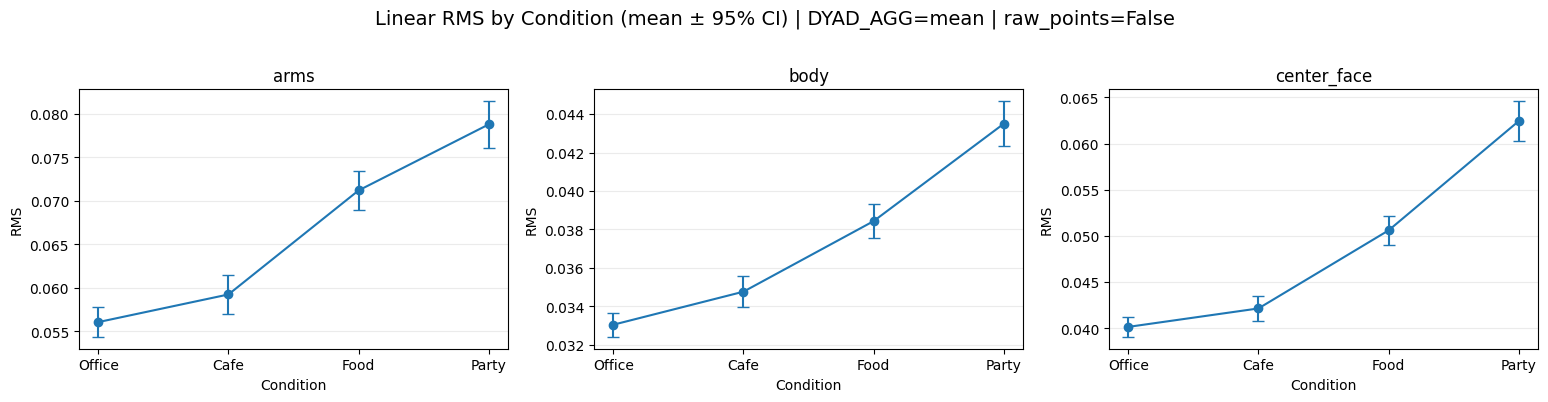

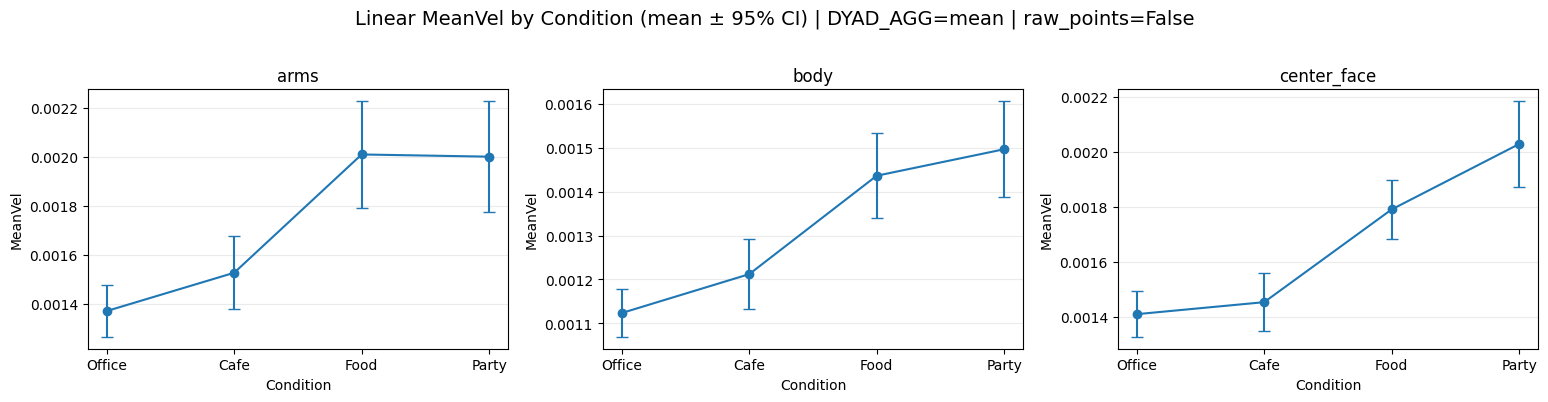

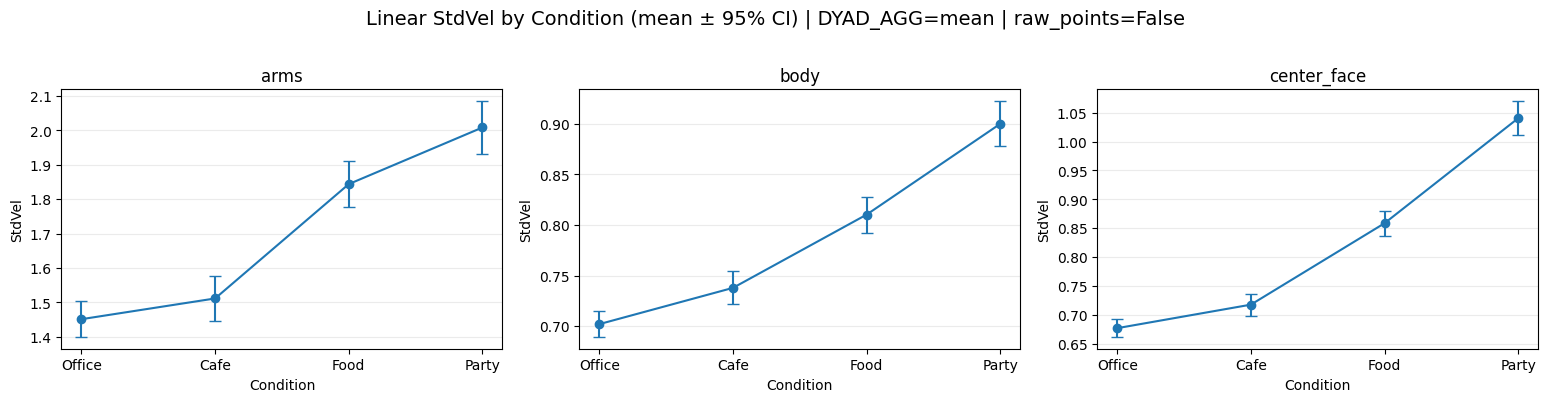

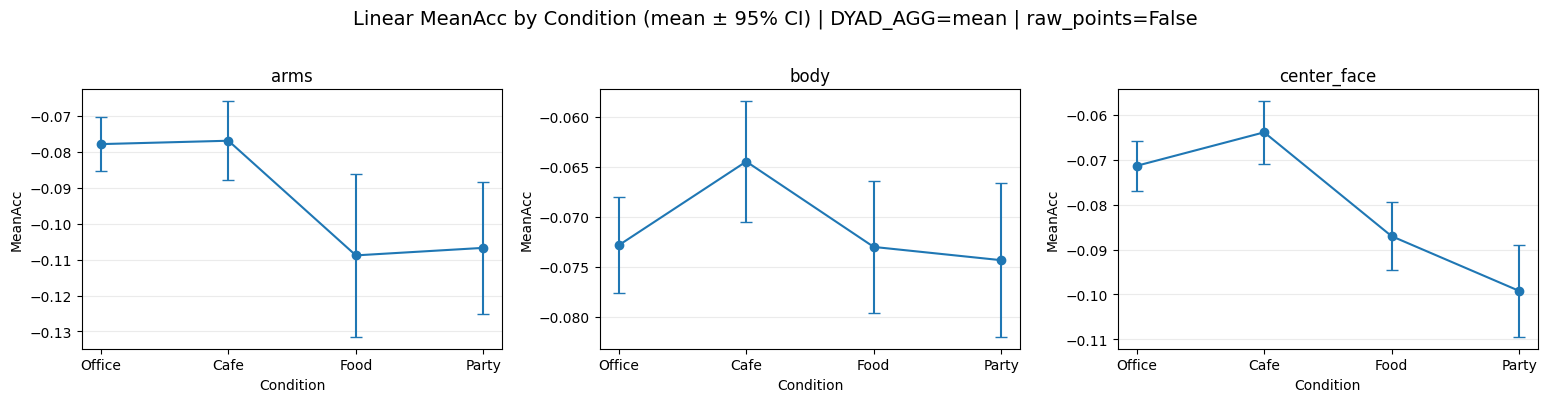

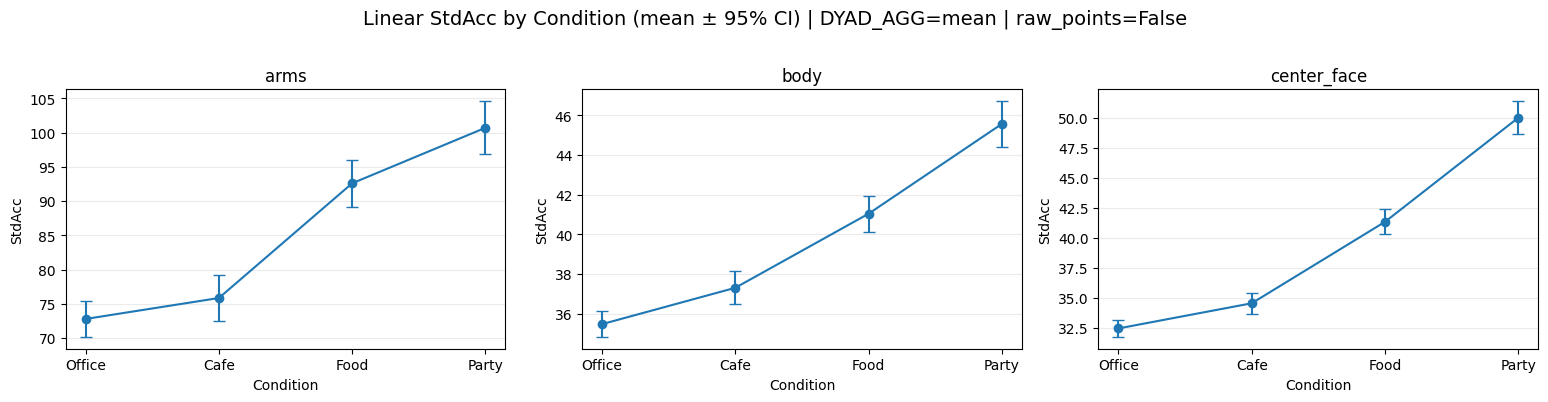

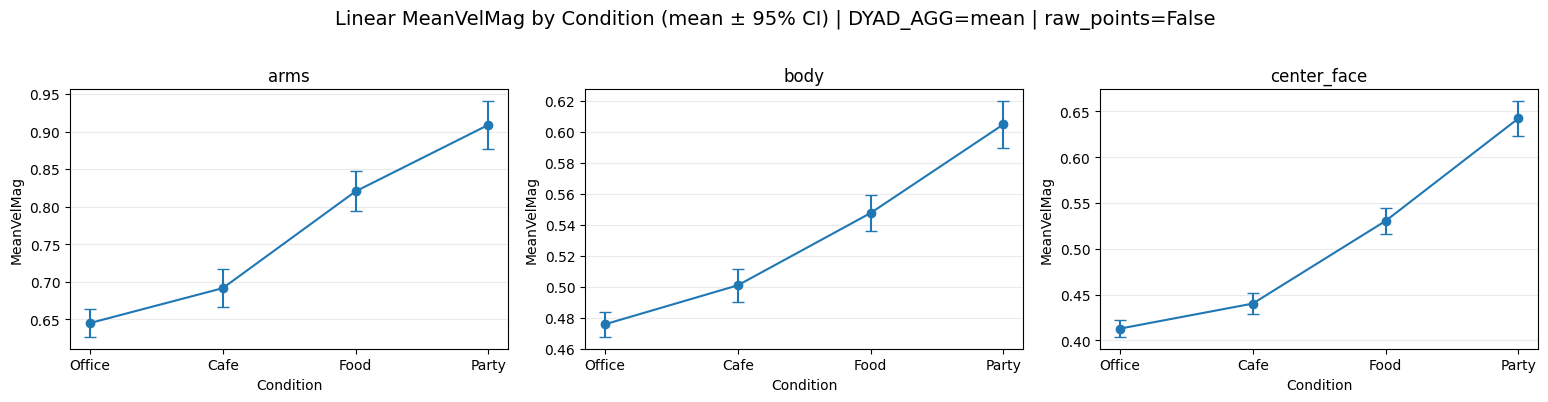

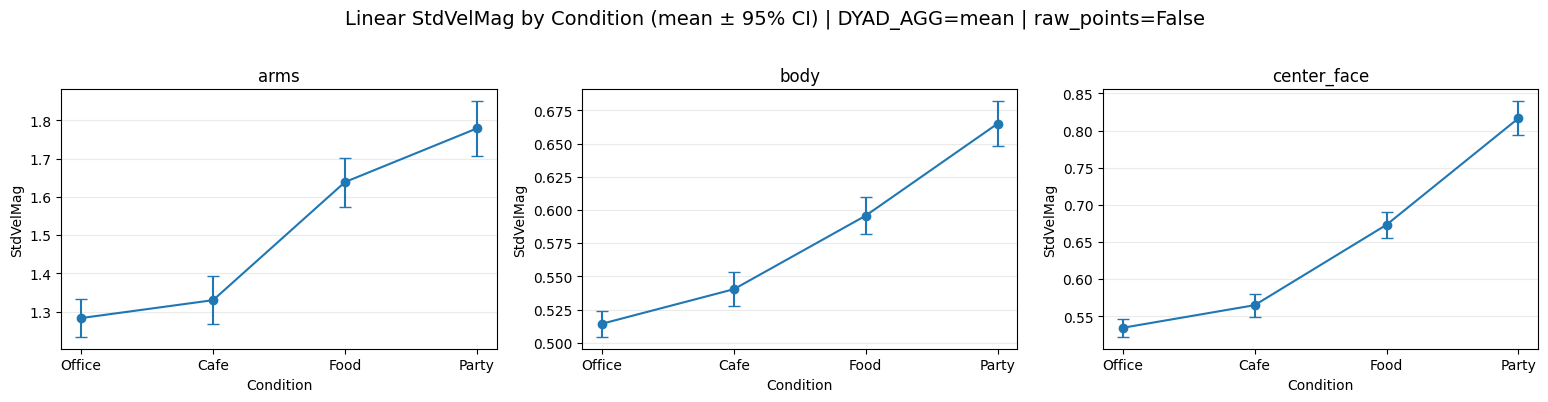

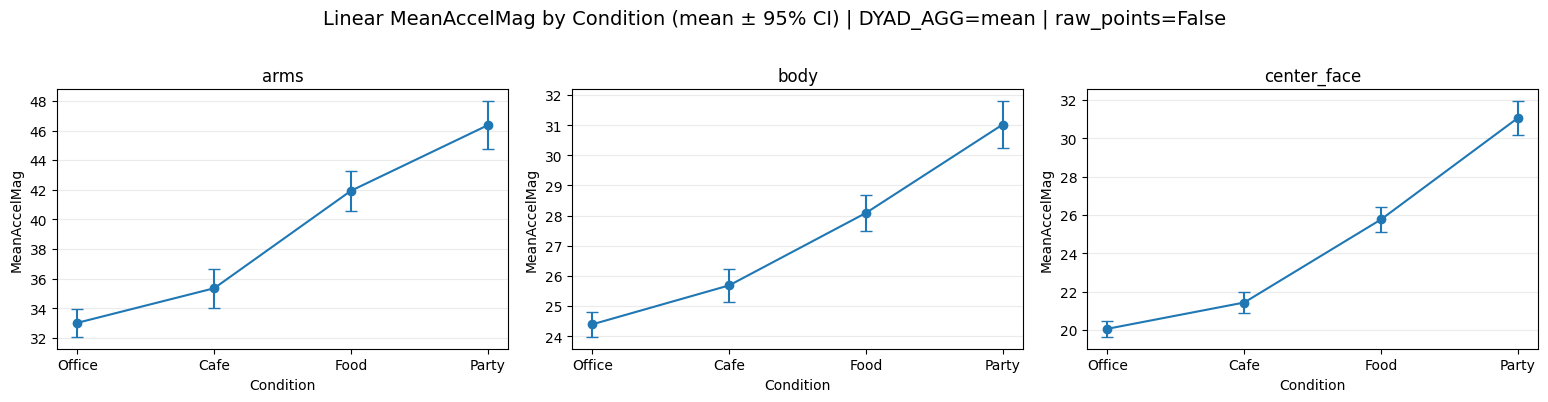

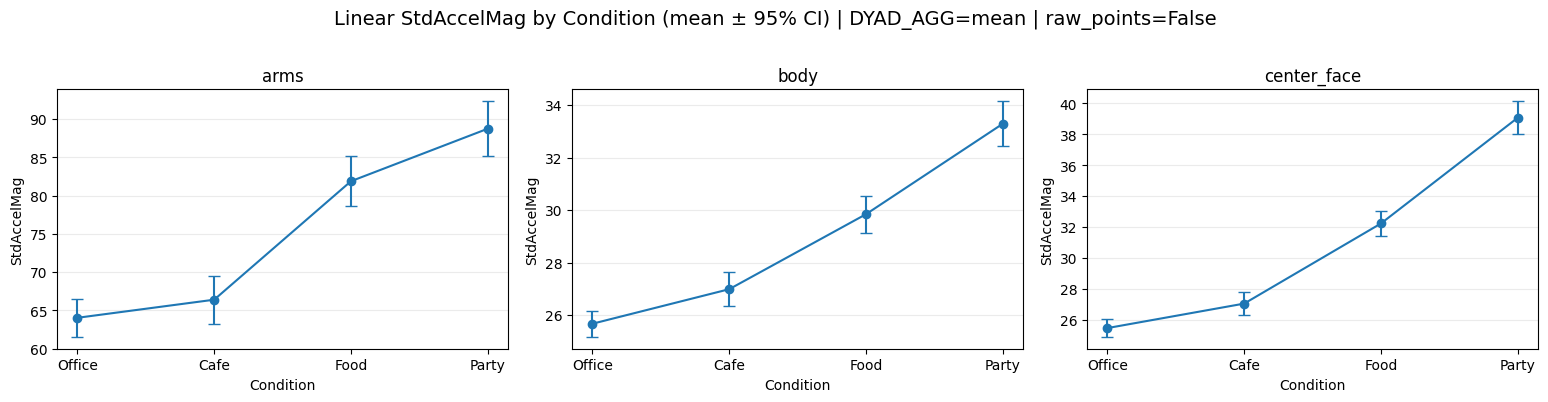

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# ============================
# Settings
# ============================
CONDITION_ORDER = ["Office", "Cafe", "Food", "Party"]
SHOW_RAW_POINTS = False          # <- set False to hide raw points
CI_Z = 1.96                     # 95% CI (normal approx)
N_COLS = 3                      # 3 plots per row
JITTER = 0.15
POINT_ALPHA = 0.25
POINT_SIZE = 12

# IMPORTANT: linear metrics are per-role.
# If you want dyad-level plots (like CRQA), use DYAD_AGG="mean".
# Options: "none" (plot roles as independent obs), "mean" (average L/R per window)
DYAD_AGG = "mean"


# ============================
# Helpers
# ============================
def _set_condition_order(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Condition"] = df["Condition"].astype(str)
    cats = [c for c in CONDITION_ORDER if c in df["Condition"].unique()]
    df["Condition"] = pd.Categorical(df["Condition"], categories=cats, ordered=True)
    return df

def _mean_ci(series: pd.Series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(np.mean(x))
    if n == 1:
        return mean, mean, mean, 1
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    lo = mean - CI_Z * se
    hi = mean + CI_Z * se
    return mean, lo, hi, n

def load_linear_results():
    base_dir = "../linear_results"
    files = [
        os.path.join(base_dir, "linear_center_face_mag.csv"),
        os.path.join(base_dir, "linear_body_mag.csv"),
        os.path.join(base_dir, "linear_arms_mag.csv"),
    ]
    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))
    if not dfs:
        raise FileNotFoundError(f"No linear ROI files found in {base_dir}.")
    df = pd.concat(dfs, ignore_index=True)

    # Basic sanity
    needed = {"ROI", "Condition", "Session", "Trial", "Window_Index"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Linear results missing columns: {missing}")

    df = _set_condition_order(df)
    return df

def maybe_aggregate_to_dyads(df: pd.DataFrame) -> pd.DataFrame:
    """
    If DYAD_AGG='mean', average Left/Right within (Session, Trial, Window_Index, ROI, Condition).
    This avoids double-counting and better matches CRQA (dyad-level).
    """
    if DYAD_AGG != "mean":
        return df

    metric_cols = [c for c in df.columns if c not in [
        "Session","Trial","Role","Condition","Window_Size","Window_Index","ROI","Vector_Type"
    ]]

    # Keep only numeric metrics
    for c in metric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    gcols = ["Session", "Trial", "Window_Index", "ROI", "Condition", "Window_Size"]
    out = (
        df.groupby(gcols, dropna=False)[metric_cols]
          .mean()
          .reset_index()
    )
    out["Role"] = "DyadMean"
    out["Vector_Type"] = "magnitude"
    out = _set_condition_order(out)
    return out

def plot_linear_by_condition_ci_grid(df: pd.DataFrame, metric: str, title: str = None):
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found. Available:\n{list(df.columns)}")

    d = df.copy()
    d = _set_condition_order(d)
    d[metric] = pd.to_numeric(d[metric], errors="coerce")

    rois = [r for r in sorted(d["ROI"].dropna().unique())]
    if not rois:
        print(f"[SKIP] No ROIs found for metric={metric}")
        return

    n = len(rois)
    nrows = ceil(n / N_COLS)
    fig, axes = plt.subplots(nrows, N_COLS, figsize=(5.2 * N_COLS, 3.9 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax in axes[n:]:
        ax.axis("off")

    for i, roi in enumerate(rois):
        ax = axes[i]
        sub = d[d["ROI"] == roi].copy()
        if sub.empty:
            ax.set_title(f"{roi} (no data)")
            ax.axis("off")
            continue

        cats = list(sub["Condition"].cat.categories)
        x = np.arange(len(cats))

        # Raw points
        if SHOW_RAW_POINTS:
            pts = sub.dropna(subset=["Condition", metric]).copy()
            if not pts.empty:
                x_codes = pts["Condition"].cat.codes.to_numpy()
                jitter = (np.random.rand(len(x_codes)) - 0.5) * (2 * JITTER)
                ax.scatter(
                    x_codes + jitter,
                    pts[metric].to_numpy(),
                    alpha=POINT_ALPHA,
                    s=POINT_SIZE,
                )

        # Mean ± CI per condition
        stats = []
        for cond in cats:
            mean, lo, hi, n_obs = _mean_ci(sub.loc[sub["Condition"] == cond, metric])
            stats.append((cond, mean, lo, hi, n_obs))
        stats_df = pd.DataFrame(stats, columns=["Condition", "mean", "lo", "hi", "n"])

        y = stats_df["mean"].to_numpy()
        yerr = np.vstack([(y - stats_df["lo"].to_numpy()), (stats_df["hi"].to_numpy() - y)])
        ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=4)

        ax.set_title(roi)
        ax.set_xticks(x)
        ax.set_xticklabels(cats)
        ax.set_xlabel("Condition")
        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.25)

    if title is None:
        title = metric
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


# ============================
# Load + (optionally) dyad-aggregate + plot
# ============================
lin_df = load_linear_results()
lin_df = maybe_aggregate_to_dyads(lin_df)

print("Loaded Linear:", lin_df.shape)
print("ROIs:", sorted(lin_df["ROI"].unique()))
print("Conditions present:", list(lin_df["Condition"].cat.categories))

# Pick the metrics you actually care about (these should exist based on your writer)
for m in ["RMS", "MeanVel", "StdVel", "MeanAcc", "StdAcc", "MeanVelMag", "StdVelMag", "MeanAccelMag", "StdAccelMag"]:
    if m in lin_df.columns:
        plot_linear_by_condition_ci_grid(
            lin_df,
            m,
            title=f"Linear {m} by Condition (mean ± 95% CI) | DYAD_AGG={DYAD_AGG} | raw_points={SHOW_RAW_POINTS}"
        )


## Pass 8. (C)RQA Condition Plots

Loaded:
  CRQA : (5190, 17)
  RQA  : (19032, 19)


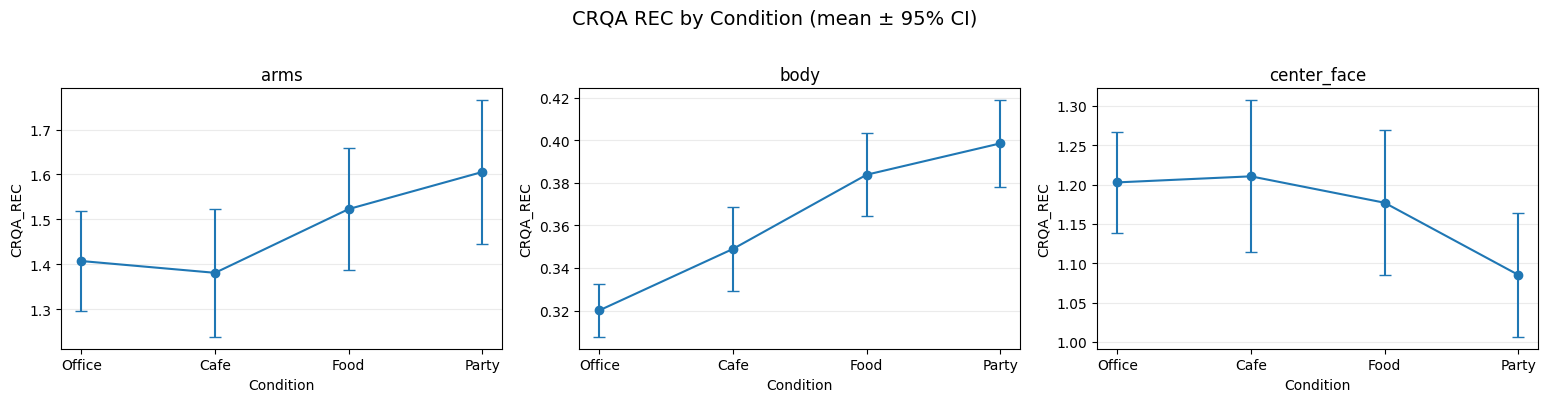

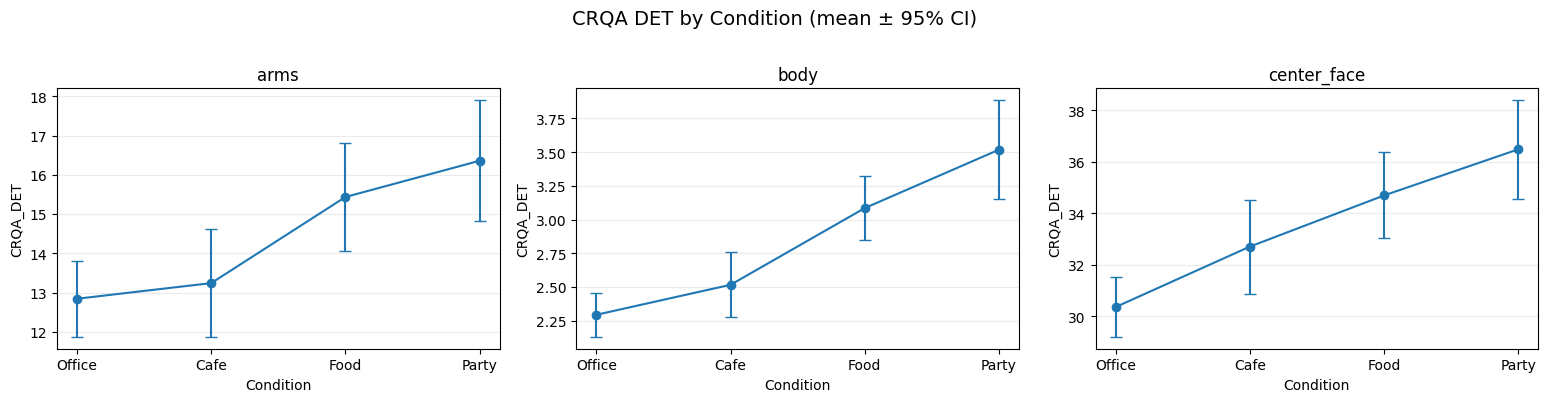

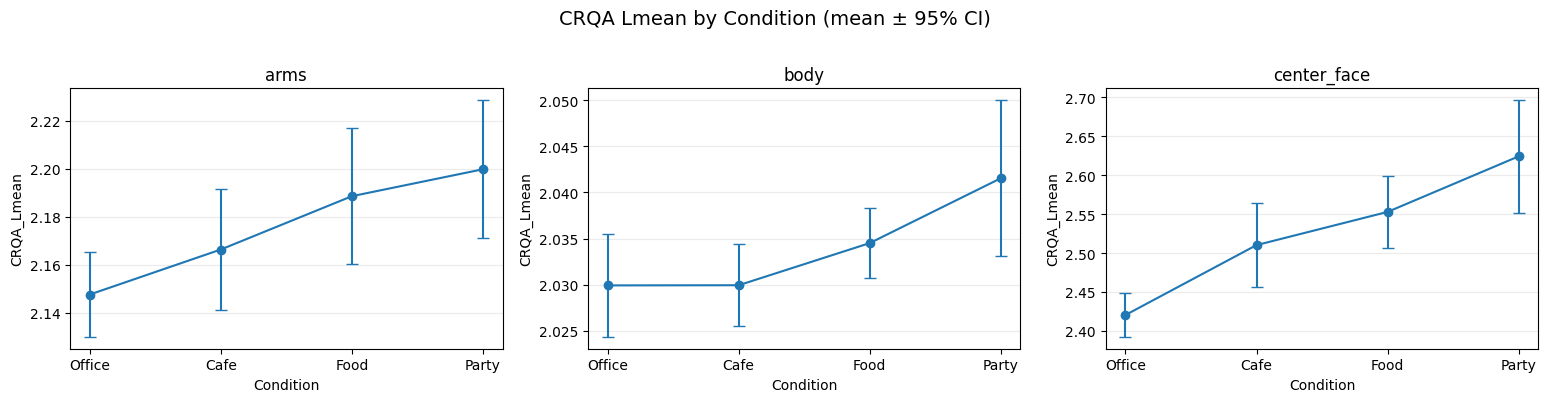

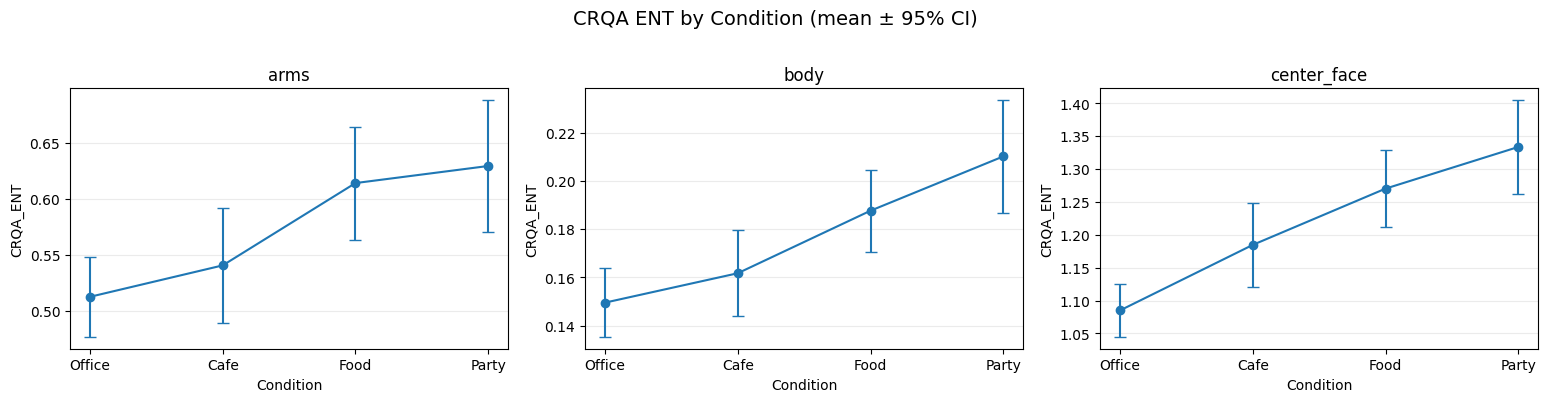

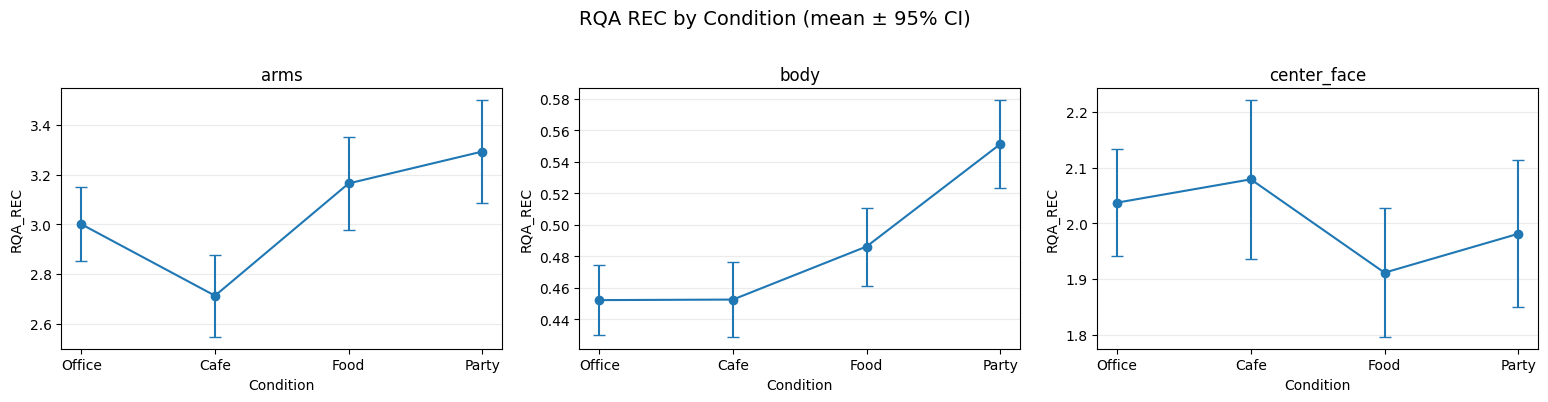

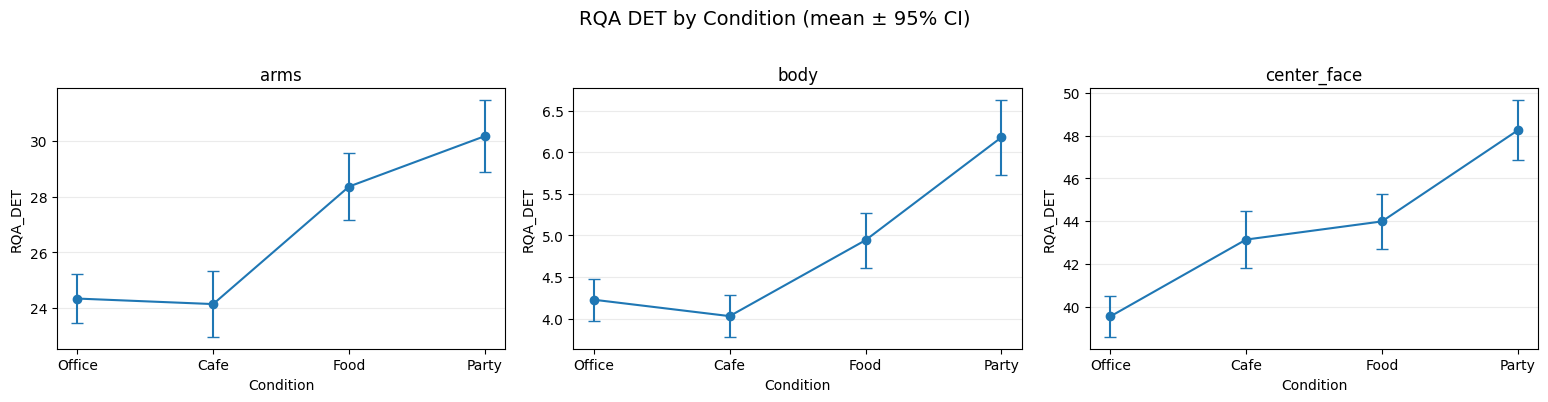

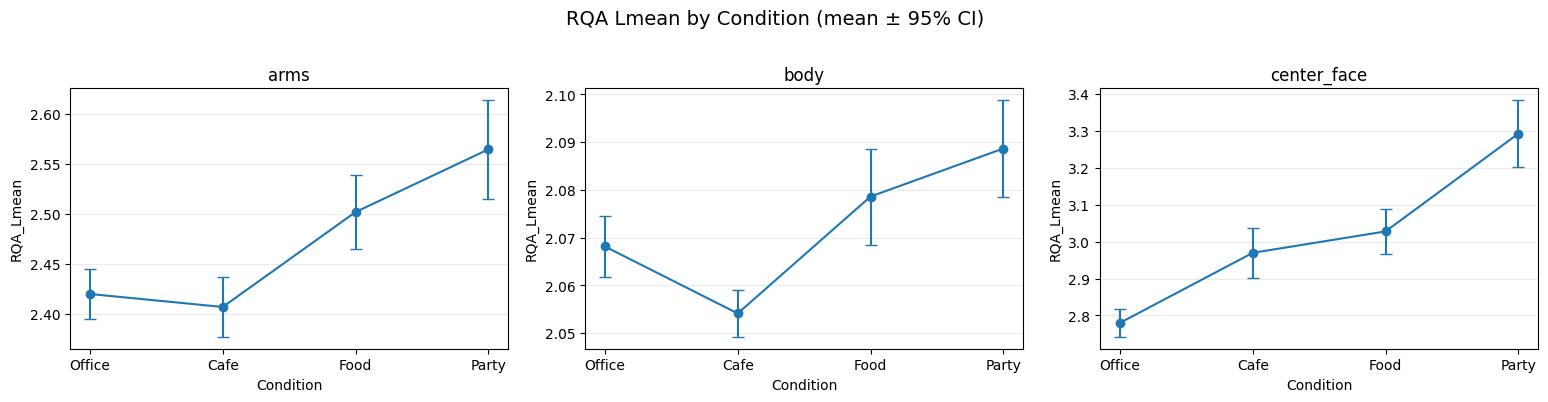

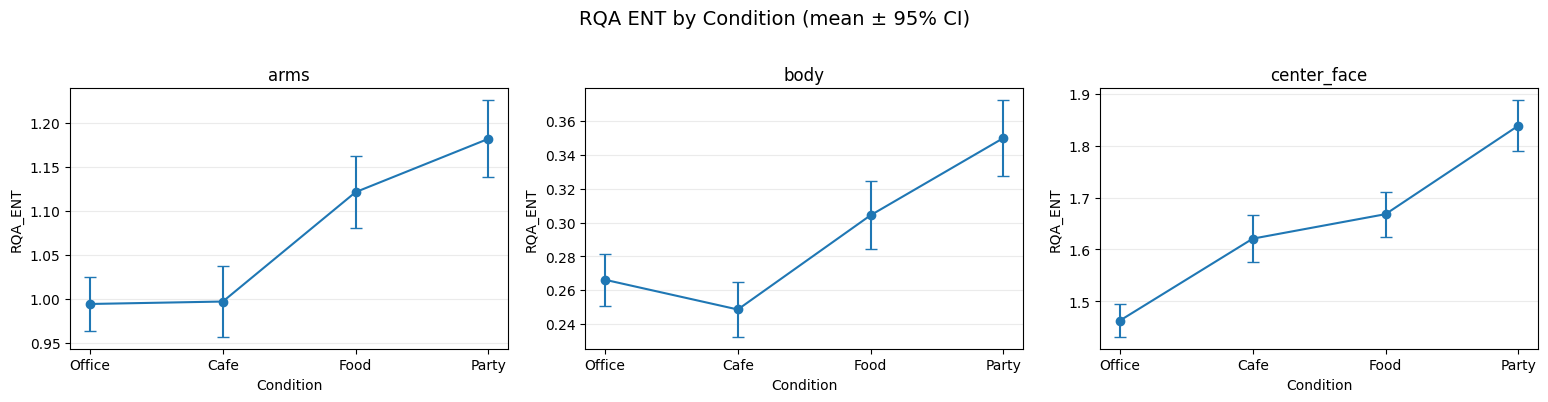

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# ============================
# User toggles
# ============================
CONDITION_ORDER = ["Office", "Cafe", "Food", "Party"]
SHOW_RAW_POINTS = False      # <-- set True to show raw points
CI_Z = 1.96                 # 95% normal approx
N_COLS = 3                  # 3 plots per row
JITTER = 0.15
POINT_ALPHA = 0.25
POINT_SIZE = 12

# ============================
# Helpers
# ============================
def _set_condition_order(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Condition"] = df["Condition"].astype(str)
    cats = [c for c in CONDITION_ORDER if c in df["Condition"].unique()]
    df["Condition"] = pd.Categorical(df["Condition"], categories=cats, ordered=True)
    return df

def _mean_ci(series: pd.Series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(np.mean(x))
    if n == 1:
        return mean, mean, mean, 1
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    lo = mean - CI_Z * se
    hi = mean + CI_Z * se
    return mean, lo, hi, n

def load_roi_results(kind: str, radius_tag: str):
    """
    kind: 'crqa' | 'rqa'
    radius_tag: e.g. 'R15' for crqa/rqa files.
    """
    base_dir = f"../{kind}_results"
    files = [
        os.path.join(base_dir, f"{kind}_center_face_mag_{radius_tag}.csv"),
        os.path.join(base_dir, f"{kind}_body_mag_{radius_tag}.csv"),
        os.path.join(base_dir, f"{kind}_arms_mag_{radius_tag}.csv"),
    ]

    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))

    if not dfs:
        raise FileNotFoundError(f"No {kind} ROI files found in {base_dir}.")

    out = pd.concat(dfs, ignore_index=True)
    if "ROI" not in out.columns or "Condition" not in out.columns:
        raise ValueError(f"{kind} results missing ROI/Condition columns.")
    out = _set_condition_order(out)
    return out

def plot_by_condition_ci_grid(df: pd.DataFrame, metric: str, title: str = None):
    """
    One subplot per ROI, mean ± 95% CI by Condition, optional raw points.
    """
    if metric not in df.columns:
        raise ValueError(
            f"Metric '{metric}' not found. Available columns include:\n{list(df.columns)}"
        )

    d = df.copy()
    d = _set_condition_order(d)

    rois = [r for r in sorted(d["ROI"].dropna().unique())]
    if not rois:
        print(f"[SKIP] No ROIs found for metric={metric}")
        return

    n = len(rois)
    nrows = ceil(n / N_COLS)
    fig, axes = plt.subplots(
        nrows, N_COLS, figsize=(5.2 * N_COLS, 3.9 * nrows), squeeze=False
    )
    axes = axes.ravel()

    for ax in axes[n:]:
        ax.axis("off")

    for i, roi in enumerate(rois):
        ax = axes[i]
        sub = d[d["ROI"] == roi].copy()

        if sub.empty:
            ax.set_title(f"{roi} (no data)")
            ax.axis("off")
            continue

        # condition stats
        stats = []
        cats = list(sub["Condition"].cat.categories)
        for cond in cats:
            mean, lo, hi, n_obs = _mean_ci(sub.loc[sub["Condition"] == cond, metric])
            stats.append((cond, mean, lo, hi, n_obs))
        stats_df = pd.DataFrame(stats, columns=["Condition", "mean", "lo", "hi", "n"])
        x = np.arange(len(cats))

        # raw points
        if SHOW_RAW_POINTS:
            pts = sub.dropna(subset=["Condition", metric]).copy()
            if not pts.empty:
                x_codes = pts["Condition"].cat.codes.to_numpy()
                jitter = (np.random.rand(len(x_codes)) - 0.5) * (2 * JITTER)
                ax.scatter(
                    x_codes + jitter,
                    pd.to_numeric(pts[metric], errors="coerce").to_numpy(),
                    alpha=POINT_ALPHA,
                    s=POINT_SIZE,
                )

        # mean + CI
        y = stats_df["mean"].to_numpy()
        yerr = np.vstack(
            [(y - stats_df["lo"].to_numpy()), (stats_df["hi"].to_numpy() - y)]
        )
        ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=4)

        ax.set_title(roi)
        ax.set_xticks(x)
        ax.set_xticklabels(cats)
        ax.set_xlabel("Condition")
        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.25)

    if title is None:
        title = metric
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


# ============================================================
# LOAD + PLOT
# ============================================================
# Use your RADII setting to build the tag, e.g., RADII=[0.15] -> R15
radius_tag = f"R{int(RADII[0]*100)}"

crqa_df = load_roi_results("crqa", radius_tag=radius_tag)
rqa_df  = load_roi_results("rqa",  radius_tag=radius_tag)

print("Loaded:")
print("  CRQA :", crqa_df.shape)
print("  RQA  :", rqa_df.shape)

# --- CRQA plots ---
plot_by_condition_ci_grid(crqa_df, "CRQA_REC",   title="CRQA REC by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_DET",   title="CRQA DET by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_Lmean", title="CRQA Lmean by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_ENT",   title="CRQA ENT by Condition (mean ± 95% CI)")

# --- RQA plots ---
plot_by_condition_ci_grid(rqa_df, "RQA_REC",   title="RQA REC by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_DET",   title="RQA DET by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_Lmean", title="RQA Lmean by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_ENT",   title="RQA ENT by Condition (mean ± 95% CI)")